In [19]:
#!/usr/bin/env python3
# evaluate.py – AR(168 h) + two-head   2025-06-04 rev2

import os, json, pickle, numpy as np, pandas as pd, matplotlib.pyplot as plt, torch
import re as regex
from tqdm.auto import tqdm
from sklearn.metrics import mean_squared_error, brier_score_loss

# ───── 使用者設定 ─────
MODEL_DIR   = "models/20250603_143112"
CSV_PATH    = "data.csv"
START_DATE  = "2025-01-01 00:00:00"
END_DATE    = "2025-01-09 23:00:00"
HISTORY     = 24
HORIZON     = 168
THR         = 0.30
TARGET_COLS = ["466920氣溫(℃)", "466920降水量(mm)"]
name_map = {
    "466920氣溫(℃)":   "Temp_466920 (°C)",
    "466920降水量(mm)": "Rain_466920 (mm)"
}
# ────────────────────

In [20]:
# 1) 模型 / Scaler / Config ────────────────────────────────────────────────
with open(os.path.join(MODEL_DIR, "config.json")) as f: cfg = json.load(f)
with open(os.path.join(MODEL_DIR, "scaler.pkl"), "rb") as f: scaler = pickle.load(f)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
from train import TwoHeadTFM
model = TwoHeadTFM(**cfg).to(DEVICE)
model.load_state_dict(torch.load(os.path.join(MODEL_DIR, "best.pt"),
                                 map_location=DEVICE))
model.eval()
precip_idx = cfg["precip_idx"]

# 2) 讀資料 + 功能工程 ─────────────────────────────────────────────────────
df = pd.read_csv(CSV_PATH)
df.rename(columns={df.columns[0]: "Datetime"}, inplace=True)
df["Datetime"] = pd.to_datetime(df["Datetime"])
df.sort_values("Datetime", inplace=True); df.reset_index(drop=True, inplace=True)
df["tod"]   = df["Datetime"].dt.hour + df["Datetime"].dt.minute / 60
df["month"] = df["Datetime"].dt.month

feat_cols = [c for c in df.columns if c != "Datetime"]
df[feat_cols] = (
    df[feat_cols]
      .mask(df[feat_cols] <= -99, np.nan)
      .interpolate(limit_direction="both")
)

# 標準化整張表
all_std = scaler.transform(df[feat_cols])

# 3) 評估期間索引 ─────────────────────────────────────────────────────────
mask      = (df["Datetime"] >= START_DATE) & (df["Datetime"] <= END_DATE)
idx_eval  = np.where(mask.values)[0]          # 全表中的「評估列」索引
N         = len(idx_eval)
assert N > HORIZON + HISTORY, "評估區間過短，請拉長 END_DATE 或減少 HORIZON"

thr_scaled = (0 - scaler.mean_[precip_idx]) / scaler.scale_[precip_idx]
print(f"Evaluate: {START_DATE} → {END_DATE} | hrs = {N}")

tgt_idx   = [feat_cols.index(c) for c in TARGET_COLS]
scale_tgt = scaler.scale_[tgt_idx]
mean_tgt  = scaler.mean_[tgt_idx]

Evaluate: 2025-01-01 00:00:00 → 2025-01-09 23:00:00 | hrs = 215


In [21]:
# 4) 緩衝區 ───────────────────────────────────────────────────────────────
K = len(TARGET_COLS)
pred_sum_std = np.zeros((N, K))
pred_cnt     = np.zeros((N, 1))
true_buf     = df.loc[mask, TARGET_COLS].values    # 真值 (N,K)
sqe          = np.zeros((K, HORIZON))
cntR         = np.zeros((K, HORIZON))
brier_s, brier_n = 0.0, 0

# 5) 自迴歸預測 ───────────────────────────────────────────────────────────
for st in tqdm(range(N - HORIZON), desc="AR rolling"):
    # ---- 取「全球」歷史 window，包含 START_DATE 之前 --------
    g_idx      = idx_eval[st]                         # 全表中的 row id
    start_hist = g_idx - HISTORY + 1
    assert start_hist >= 0, "資料開頭不足以提供 24 h 歷史"
    win = all_std[start_hist : g_idx + 1].copy()      # (24,F)

    pred_buf_std = np.zeros((HORIZON, K))

    for h in range(HORIZON):
        x = torch.tensor(win[-HISTORY:][None],
                         dtype=torch.float32).to(DEVICE)
        with torch.no_grad():
            p_hat, amt_hat, oth_hat = model(x)
        p_hat   = p_hat.cpu().numpy()[0]
        amt_hat = amt_hat.cpu().numpy()[0]
        oth_hat = oth_hat.cpu().numpy()[0]

        full = np.zeros(len(feat_cols), dtype=np.float32)
        full[precip_idx] = amt_hat
        full[[i for i in range(len(feat_cols)) if i not in precip_idx]] = oth_hat
        win = np.vstack([win, full])                  # 把預測塞進 window

        rain_amt = (p_hat > THR).astype(float) * amt_hat
        out_full = full.copy(); out_full[precip_idx] = rain_amt
        pred_buf_std[h] = out_full[tgt_idx]

        brier_s += brier_score_loss((win[-2, precip_idx] > thr_scaled).astype(int),
                                    p_hat)
        brier_n += 1

    rel_start = st + 1
    rel_end   = rel_start + HORIZON
    pred_sum_std[rel_start:rel_end] += pred_buf_std
    pred_cnt[rel_start:rel_end]     += 1

    # 反標準化計 RMSE
    pred_buf = pred_buf_std * scale_tgt + mean_tgt
    truth    = df.iloc[idx_eval[rel_start:rel_end]][TARGET_COLS].values
    err2     = (pred_buf - truth) ** 2
    sqe     += err2.T
    cntR    += 1


AR rolling: 100%|██████████| 47/47 [00:35<00:00,  1.32it/s]



===== RMSE Summary =====
                  WeeklyAvg_RMSE  First24h_RMSE  Last24h_RMSE
Temp_466920 (°C)          11.622          8.499        12.872
Rain_466920 (mm)           3.965          1.443         7.101

Brier score (mean over precip heads) : 0.1720


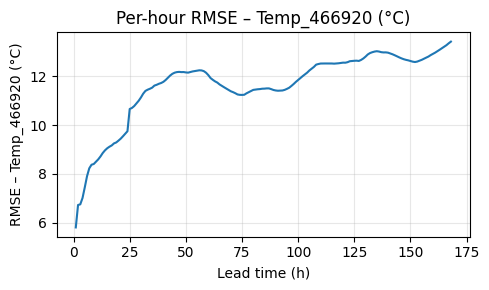

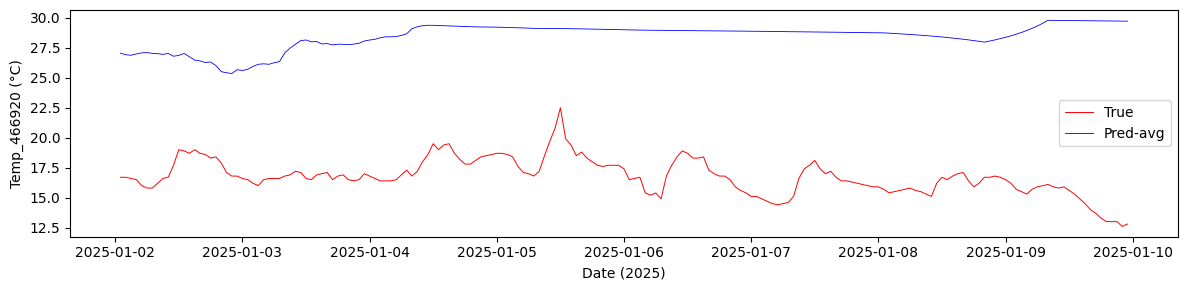

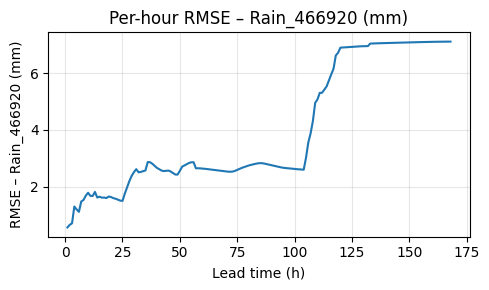

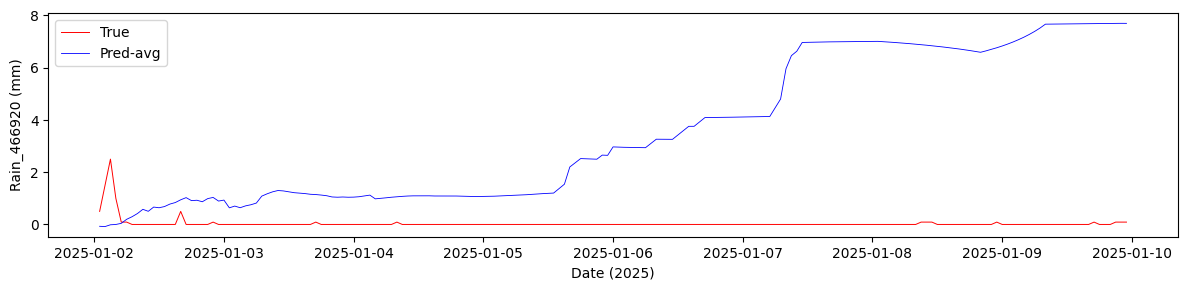

In [22]:
# 6) 結果統計 + 畫圖 ──────────────────────────────────────────────────────
avg_pred_std = pred_sum_std / np.where(pred_cnt == 0, 1, pred_cnt)
avg_pred     = avg_pred_std * scale_tgt + mean_tgt
rmse         = np.sqrt(sqe / cntR)

summary = pd.DataFrame({
    "WeeklyAvg_RMSE": rmse.mean(axis=1),
    "First24h_RMSE":  rmse[:, :24].mean(axis=1),
    "Last24h_RMSE":   rmse[:, -24:].mean(axis=1)
}, index=[name_map.get(c, c) for c in TARGET_COLS]).round(3)
print("\n===== RMSE Summary =====")
print(summary)
print(f"\nBrier score (mean over precip heads) : {brier_s / brier_n:.4f}")

def safe(s): return regex.sub(r"[^\w一-龥]+", "_", s)

skip = HISTORY
dt_plot   = df.loc[idx_eval[skip:], "Datetime"].values
true_plot = true_buf[skip:]
pred_plot = avg_pred[skip:]
hours     = np.arange(1, HORIZON + 1)

for i, col in enumerate(TARGET_COLS):
    label = name_map.get(col, col)

    # (A) lead-time RMSE
    plt.figure(figsize=(5, 3))
    plt.plot(hours, rmse[i]); plt.grid(alpha=.3)
    plt.xlabel("Lead time (h)"); plt.ylabel(f"RMSE – {label}")
    plt.title(f"Per-hour RMSE – {label}"); plt.tight_layout()
    plt.savefig(os.path.join(MODEL_DIR, f"rmse_{safe(label)}.png"))
    plt.show()

    # (B) True vs Pred-avg 時序
    plt.figure(figsize=(12, 3))
    plt.plot(dt_plot, true_plot[:, i], 'r', lw=.7, label="True")
    plt.plot(dt_plot, pred_plot[:, i], 'b', lw=.6, label="Pred-avg")
    plt.ylabel(label); plt.xlabel("Date (2025)")
    plt.legend(); plt.tight_layout()
    plt.savefig(os.path.join(MODEL_DIR, f"ts_{safe(label)}.png"))
    plt.show()